RNN - Erro dos pesos computados e usado somente durante a iteração

In [4]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import matplotlib.cm as cm

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from Testing.RTLO import *
from Functions.RLS import *



In [95]:
def f(x):
    return np.tanh(x)
def d_f(x):
    return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow
def split_matrix(A):
    Ap = np.where(A > 0, A, 0)
    An = np.where(A < 0, A, 0)
    return An, Ap

def get_interval(A):
    v_max = np.max(A, axis=0)
    v_min = np.min(A, axis=0)
    
    return v_min, v_max

class RTLO:
    def __init__(self, nIN, nHS, nOUT,ηS=[0.1,0.1,0.1], τ=10,decay=1e-5):
        np.random.seed(42)
        self.nIN = nIN
        self.nHS = nHS
        self.nOUT = nOUT
        self.ΔOUT = np.zeros((nOUT, nHS))
        self.ΔHS = np.zeros((nHS, nHS))
        self.ΔIN = np.zeros((nHS, nIN))
        self.xI = np.zeros(nIN)
        self.ηS = np.array(ηS)
        self.τ = τ
        self.h0 = 0
        self.hI = np.zeros(nHS)
        self.hF = np.zeros(nHS)
        self.ht = np.zeros(nHS)
        self.htI = np.zeros((nHS,2))
        self.htL = np.zeros(nHS)
        self.htU = np.zeros(nHS)
        self.k = 0
        self.u = None
        self.decay = decay
        self.wIN = 0.1*(np.random.rand(nHS, nIN) - 1)
        self.wHS = 1.5*np.random.randn(nHS, nHS)/nHS**0.5
        self.wOUT = 0.1*(2*np.random.rand(nOUT, nHS) - 1)/nHS**0.5
        self.b = np.random.randn(nHS, nOUT)/nOUT**0.5
        self.p = np.zeros((self.nHS, self.nHS))
        self.q = np.zeros((self.nHS, self.nIN))
        self.wIN = self.xavier_uniform([nHS, nIN])
        self.wHS = self.xavier_uniform([nHS, nHS])
        self.wOUT = self.xavier_uniform([nOUT, nHS])
        self.b = np.random.randn(nHS, nOUT)/nOUT**0.5
        self.rls = RLS_LogarithmicRegressor(0.9,10000)

    def fit(self, x, y, tip=1):
        self.ηS = self.ηS/(1 + self.decay*self.k)
        η1,η2,η3 = self.ηS
        self.u = np.dot(self.nHS,self.hI) + np.dot(self.wIN,x)
        self.hF = self.hI + (1/self.τ)*(-self.hI + f(self.u))
        yP = np.dot(self.wOUT, self.hF)
        e = y - yP
        self.p = np.outer(d_f(self.u),self.hI)/self.τ + (1-1/self.τ)*self.p
        self.q = np.outer(d_f(self.u),self.xI)/self.τ + (1-1/self.τ)*self.q
        δOUT = η1*np.outer(e,self.hF)
        δHS = η2*np.outer(np.dot(self.b, e),np.ones(self.nHS))*self.p
        δIN = η3*np.outer(np.dot(self.b, e),np.ones(self.nIN))*self.q

        self.ΔOUT = (self.ΔOUT*self.k/(self.k+1)) + (δOUT/(self.k+1))
        self.ΔHS = (self.ΔHS*self.k/(self.k+1)) + (δHS/(self.k+1))
        self.ΔIN =  (self.ΔIN*self.k/(self.k+1)) + (δIN/(self.k+1))

        self.wIN = self.wIN + self.ΔIN * tip
        self.wHS = self.wHS + self.ΔHS * tip
        self.wOUT = self.wOUT + self.ΔOUT * tip

        self.hI = self.hF
        self.ht = self.hF
        self.htL = self.hF
        self.htU = self.hF
        self.ht2 = self.hF
        self.xI = x

    def PredSingle(self,x):
        #print(self.ht)
        self.htI = np.array(split_matrix(self.ht)).T
        u = np.dot(self.wHS, self.ht) + np.dot(self.wIN, x)
        h = self.ht + (-self.ht + f(u))/self.τ
        y = np.dot(self.wOUT, h)
        self.ht = h
        return y
    
    import numpy as np


    def PredInterval(self, x, e):
        x_interval = np.array(get_interval([x-e,x+e])).T

        #self.htI = np.array(split_matrix(self.ht)).T
        #print(np.array([split_matrix(self.ht)]))

        wHS_p, wHS_n = np.maximum(0, self.wHS), np.minimum(0, self.wHS)
        wIN_p, wIN_n = np.maximum(0, self.wIN), np.minimum(0, self.wIN)
        wOUT_p, wOUT_n = np.maximum(0, self.wOUT), np.minimum(0, self.wOUT)

        u_hs_low = wHS_p @ self.htI[:, 0] + wHS_n @ self.htI[:, 1]
        u_hs_high = wHS_p @ self.htI[:, 1] + wHS_n @ self.htI[:, 0]
        
        u_in_low = wIN_p @ x_interval[:, 0] + wIN_n @ x_interval[:, 1]
        u_in_high = wIN_p @ x_interval[:, 1] + wIN_n @ x_interval[:, 0]
        
        u_low = u_hs_low + u_in_low
        u_high = u_hs_high + u_in_high
        u_int = np.column_stack((u_low, u_high))

        h_target = f(u_int) # Returns (hidden_dim, 2)

        diff_low = h_target[:, 0] - self.htI[:, 1]
        diff_high = h_target[:, 1] - self.htI[:, 0]

        
        h_low = self.htI[:, 0] + diff_low / self.τ
        h_high = self.htI[:, 1] + diff_high / self.τ
        
        h_new = np.column_stack((h_low, h_high))

        y_low = wOUT_p @ h_low + wOUT_n @ h_high
        y_high = wOUT_p @ h_high + wOUT_n @ h_low
        
        #self.htI = h_new
        return np.column_stack((y_low, y_high))
    
    def CalcInterval(self,x,e):

        #print(x)
        xInterv = np.array([x-e,x+e])
        xL,xU = get_interval(xInterv)
        
        htL, htU = split_matrix(self.ht)
        self.htL, self.htU = htL, htU

        whsL, whsP = split_matrix(self.wHS)
        winL, winP = split_matrix(self.wIN)
        
        aL = (np.dot(whsP, htL) + np.dot(whsL, htU))
        aU = (np.dot(whsP, htU) + np.dot(whsL, htL))
        a = np.array([aL,aU]).T

        bL = (np.dot(winP, xL) + np.dot(winL, xU))
        bU = (np.dot(winP, xL) + np.dot(winL, xU))
        b = np.array([bL,bU]).T

        u = (a+b).T
        uL,uU = get_interval(u)
        htL = self.htL + (-self.htL + f(uL))/self.τ
        htU = self.htU + (-self.htU + f(uU))/self.τ

        print(u)
        print(uL)
        print(uU)
    
    def restore(self):
        self.ht = self.hF
        self.ht2 = self.hF
        #self.htI = self.hF
    
    def xavier_uniform(self,shape):
        np.random.seed(42)
        n_in, n_out = shape
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, size=shape)


In [3]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
n,nIN,nOUT,nHS=4,3,3,3

sig = df['PC1'].values
hi = np.array([sig[i:n+i] for i in range(len(sig)-n+1)])
X = np.array([hi[i][:nIN] for i in range(len(hi))])
Y = np.array([hi[i][-nOUT:] for i in range(len(hi))])

In [4]:
yR,yP = np.array([]),np.array([])
xR = np.array([])
yV = []
xV=[]
i = 0
rtlo = RTLO(nIN,nHS,nOUT)
for x,y in zip(X,Y):
    y_p = rtlo.PredSingle(x)
    rtlo.restore()
    y_v = rtlo.PredMulti(x,Thrs=0.2,stps=len(X))
    rtlo.restore()
    rtlo.fit(x,y)
    yR = np.append(yR,y[-1])
    yP = np.append(yP,y_p[-1])
    yV.append(y_v)
    x_v = np.arange(len(y_v)) + i
    xV.append(x_v)
    xR = np.append(xR,i)
    i = i+1

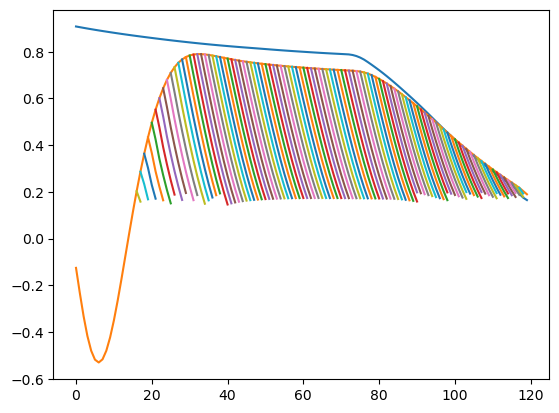

In [6]:
plt.plot(xR,yR)
plt.plot(xR,yP)
for x,y in zip(xV,yV):
    plt.plot(x,y,label=f'{i+1}')

In [96]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
n,nIN,nOUT,nHS=4,3,3,3

sig = df['PC1'].values
hi = np.array([sig[i:n+i] for i in range(len(sig)-n+1)])
X = np.array([hi[i][:nIN] for i in range(len(hi))])
Y = np.array([hi[i][-nOUT:] for i in range(len(hi))])

yR,yP = np.array([]),np.array([])
yL,yU = np.array([]),np.array([])
xR = np.array([])
i = 0


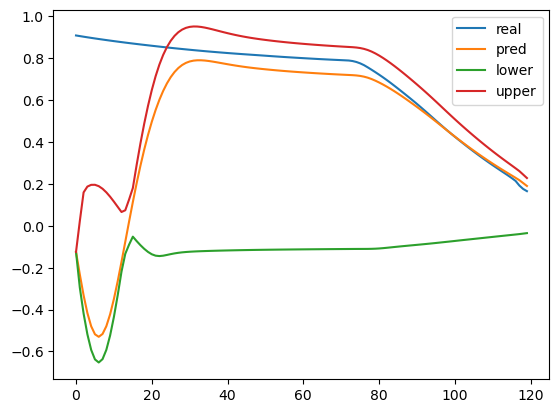

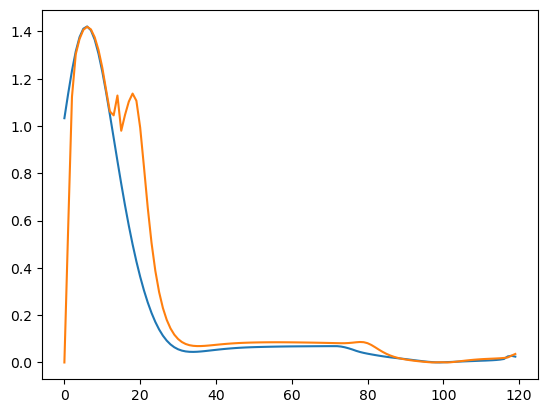

In [97]:
rtlo = RTLO(nIN,nHS,nOUT)
yR,yP = np.array([]),np.array([])
yL,yU = np.array([]),np.array([])
xR = np.array([])
erroR = np.array([])
erroP = np.array([])

for i in range(len(X)):
    y_p = rtlo.PredSingle(X[i])
    
    rtlo.restore()

    '''eP = np.zeros(len(Y[i]))
    for j,e in enumerate(eP):
        eP[j] = np.abs(rtlo.rls.predict(np.abs(y_p[j])))
    eR = np.abs(y_p-Y[i])
    for p,e in zip(y_p,eR):
        rtlo.rls.update(np.abs(p), e)
    erroR = np.append(erroR,eR[-1])
    erroP = np.append(erroP,eP[-1])'''
    
    #print(eP)
    eP = np.abs(rtlo.rls.predict(np.abs(y_p[-1])))
    eR = np.abs(y_p-Y[i])[-1]
    rtlo.rls.update(np.abs(y_p[-1]), eR)
    erroR = np.append(erroR,eR)
    erroP = np.append(erroP,eP)
    

    y_L, y_U = rtlo.PredInterval(X[i],eP)[-1]
    rtlo.restore()
    rtlo.fit(X[i],Y[i])
    yR = np.append(yR,Y[i][-1])
    yP = np.append(yP,y_p[-1])
    yL = np.append(yL,y_L)
    yU = np.append(yU,y_U)
    xR = np.append(xR,i)
    
    #i = i+1

plt.plot(xR,yR,label='real')
plt.plot(xR,yP,label='pred')
plt.plot(xR,yL,label='lower')
plt.plot(xR,yU,label='upper')
plt.legend()
plt.show()
plt.plot(erroR)
plt.plot(erroP)
